In [13]:
from matplotlib import pyplot as plt
from functions import *

# BV and Ru(bpy)3 stock solutions now made in pH 6 buffer
# mixing limitations in cuvette, colour gradient seen

# V(Ru(bpy)3, 1 mM, buffer) = 200 ul, V(EDTA, saturated, buffer) = 1 ml, made up to 3 ml pH 6 buffer
# V(BV, 1 mM, buffer) in ul used and start times for each run, start time adjusted slightly to begin at linear region

XV = r"[BV$^{+\!\cdot\!}$]" # [XV+.]
XV0 = r"[BV$^{2\!+\!}$]$_0$" # [XV2+]0

root = "./results/260701_Rubpy_BV_EDTA_Buffered"

XV = r"[BV$^{+\!\cdot\!}$]" # [XV+.]
XV0 = r"[BV$^{2\!+\!}$]$_0$" # [XV2+]0
peak = 540 # nm
e = 1.4e6 # M-1 m-1
l = 1e-2 # m
cstock = 1e-3 # [XV] in stock solution
vsol = 3e-3 # total volume of reaction mixture

runs = [(300, "11-46-40-000"), # 11-46-26-000 recorded start time
        (600, "12-21-16-000"), # 12-21-16-000
        (900, "12-55-19-000"), # 12-55-19-000
        (1200, "13-36-05-000"), # 13-36-05-000
        (1500, "14-12-42-000"), # 14-12-42-000
        (1800, "16-40-13-000")] # 16-40-13-000

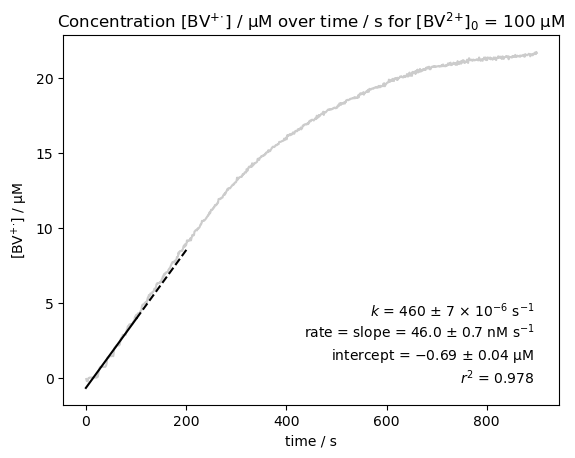

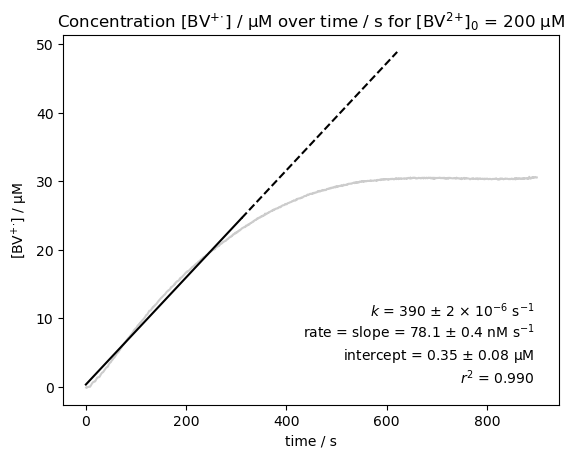

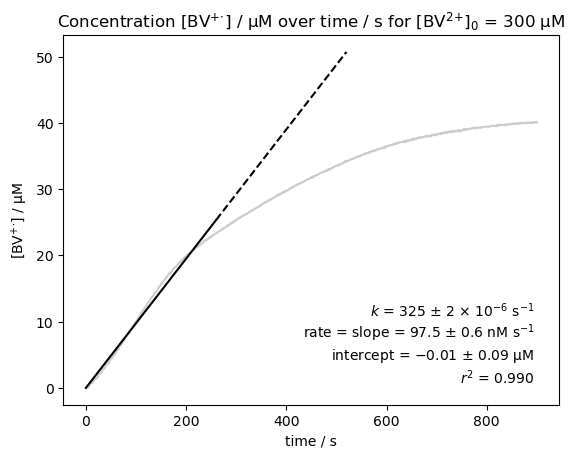

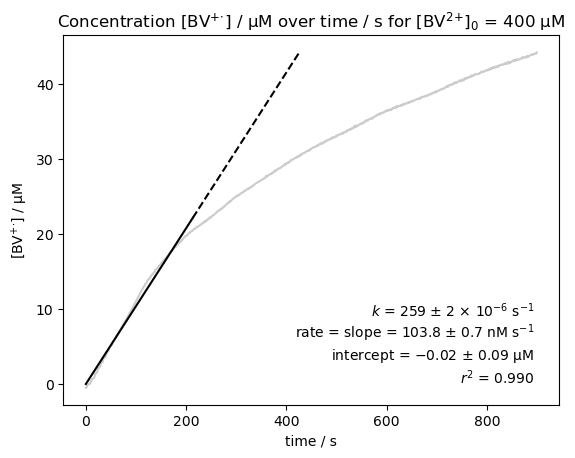

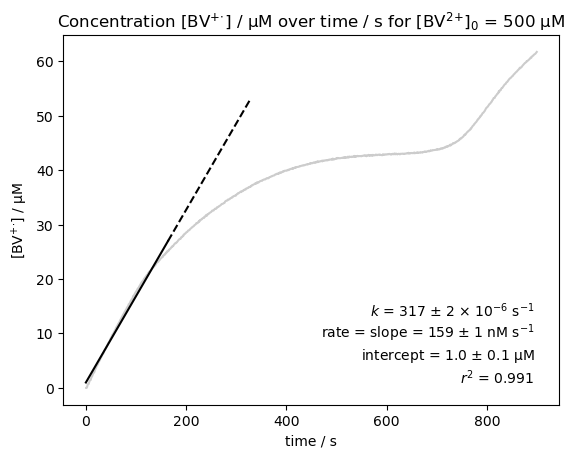

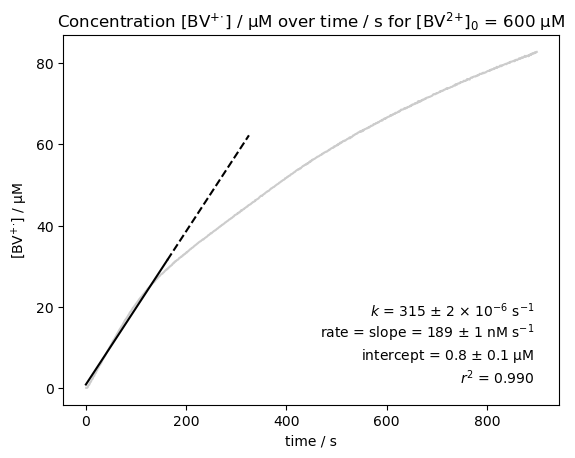

In [14]:
# concentration vs time plot for each run
for (v, start) in runs:
    data = f'{root}/Rubpy_BV_{v}_EDTA_Buffered'
    c0 = solprop(cstock=cstock, valiquot=v*1e-6, vsol=vsol) # initial XV2+ concentration
    t, c = concvstime(data, peak, e, l, start=start, duration=15*60)
    plt.plot(t, [conc*1e6 for conc in c], color="black", alpha=0.2) # plot time in s, concentrations in μM
    plt.xlabel(r'time / s')
    plt.ylabel(rf'{XV} / μM')
    plt.title(rf'Concentration {XV} / μM over time / s for {XV0} = {c0*1e6:.0f} μM')
    
    fit, i = linreg(t, c, istart=100, r2threshold=0.99, interceptthreshold=1e-6)
    x1 = np.linspace(0, t[i], 100) # plot linear regression line over the initial linear region
    y1 = (fit.slope*x1 + fit.intercept)*1e6
    plt.plot(x1, y1, color="black")
    x2 = np.linspace(t[i], t[i]*2, 100) # extrapolate linear regression line
    y2 = (fit.slope*x2 + fit.intercept)*1e6
    plt.plot(x2, y2, color="black", linestyle="--")
    plt.text(0.95, 0.05,
         rf'$k$ = {errformat(fit.slope/c0, fit.stderr/c0, prefix=1e-6)} $\times$ 10$^{{-6}}$ s$^{{-1}}$''\n'
         rf'rate = slope = {errformat(fit.slope, fit.stderr, prefix=1e-9)} nM s$^{{-1}}$''\n'
         f'intercept = {errformat(fit.intercept, fit.intercept_stderr, prefix=1e-6)} µM\n'
         f'$r^2$ = {fit.rvalue**2:.3f}',
         transform=plt.gca().transAxes, ha="right", va="bottom")
    plt.show()

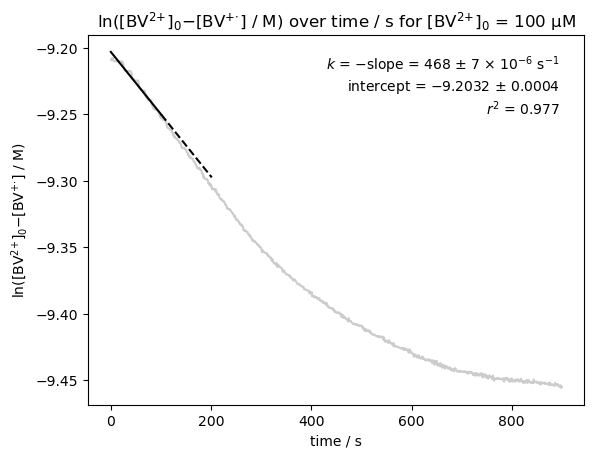

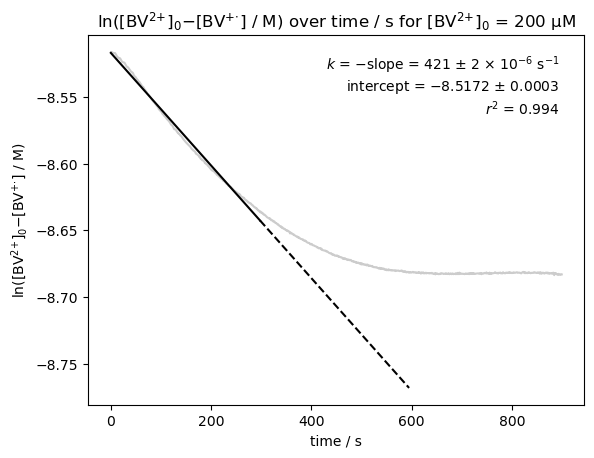

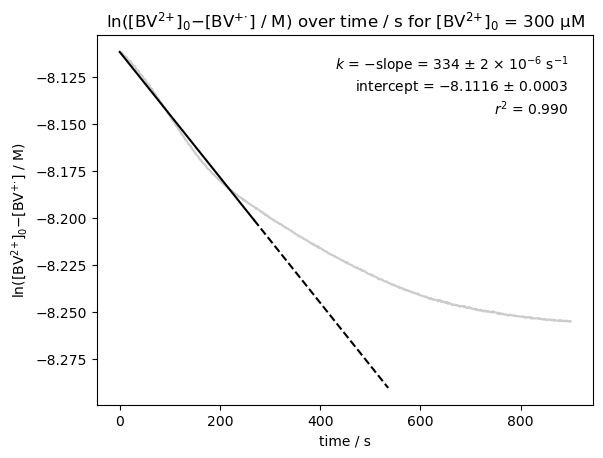

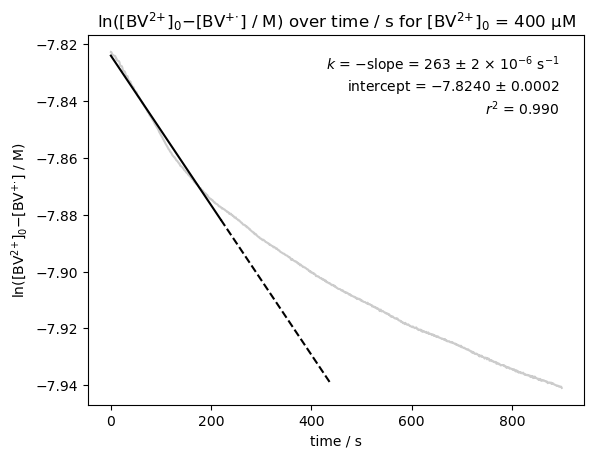

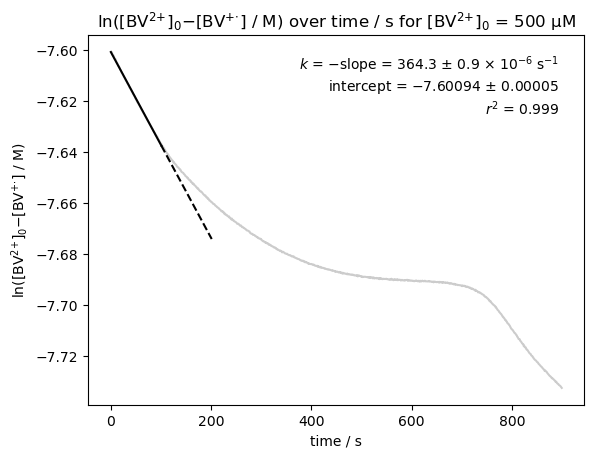

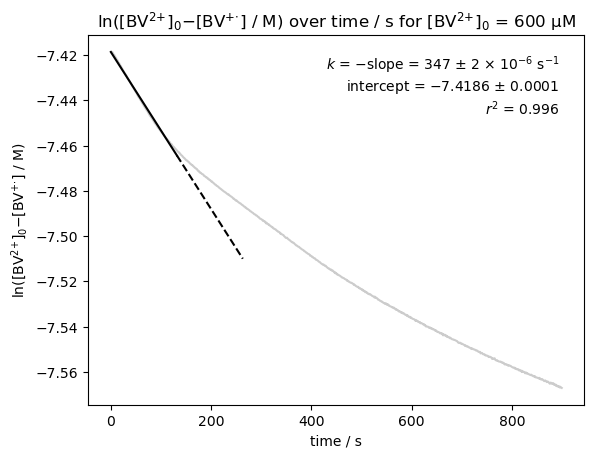

In [15]:
# ln vs time plot for each run
for (v, start) in runs:
    data = f'{root}/Rubpy_BV_{v}_EDTA_Buffered'
    c0 = solprop(cstock=cstock, valiquot=v*1e-6, vsol=vsol) # initial XV2+ concentration
    t, c = concvstime(data, peak, e, l, start=start, duration=15*60)
    lnc = [np.log(c0-conc) for conc in c]
    plt.plot(t, lnc, color="black", alpha=0.2) # plot time in seconds, concentrations in μM
    plt.xlabel(r'time / s')
    plt.ylabel(rf'ln({XV0}$-${XV} / M)')
    plt.title(rf'ln({XV0}$-${XV} / M) over time / s for {XV0} = {c0*1e6:.0f} μM')
    
    fit, i = linreg(t, lnc, istart=100, r2threshold=0.99, interceptthreshold=np.log(c0))
    x1 = np.linspace(0, t[i], 100) # plot linear regression line over the initial linear region
    y1 = (fit.slope*x1 + fit.intercept)
    plt.plot(x1, y1, color="black")
    x2 = np.linspace(t[i], t[i]*2, 100) # extrapolate linear regression line
    y2 = (fit.slope*x2 + fit.intercept)
    plt.plot(x2, y2, color="black", linestyle="--")
    plt.text(0.95, 0.95,
         rf'$k$ = $-$slope = {errformat(-fit.slope, fit.stderr, prefix=1e-6)} $\times$ 10$^{{-6}}$ s$^{{-1}}$''\n'
         f'intercept = {errformat(fit.intercept, fit.intercept_stderr, sci=False)}\n'
         f'$r^2$ = {fit.rvalue**2:.3f}',
         transform=plt.gca().transAxes, ha="right", va="top")
    plt.show()

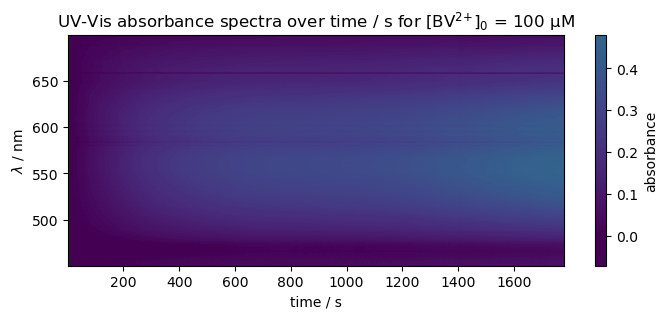

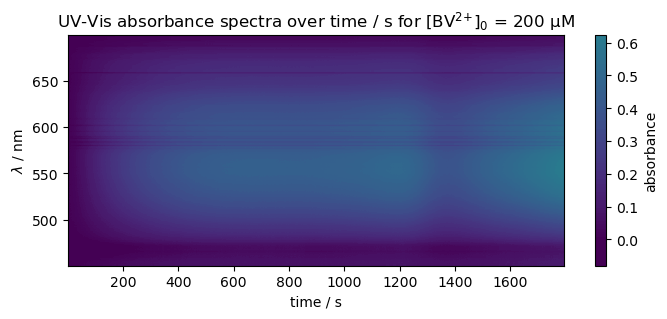

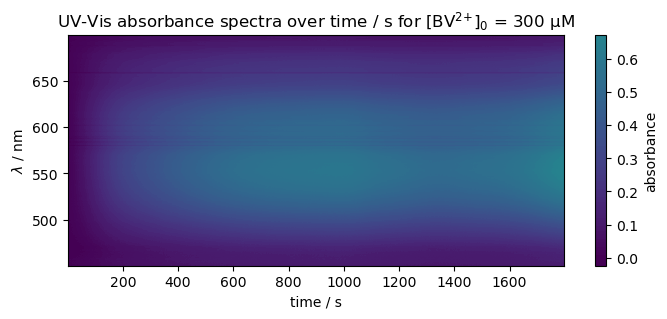

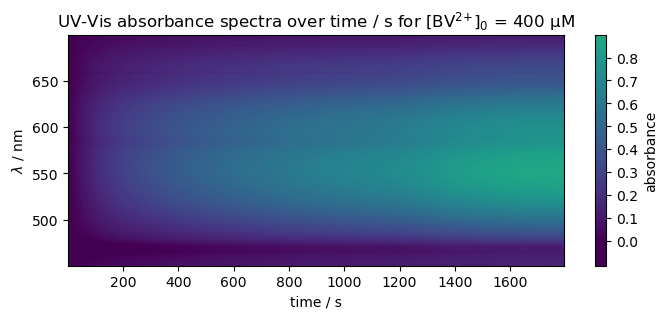

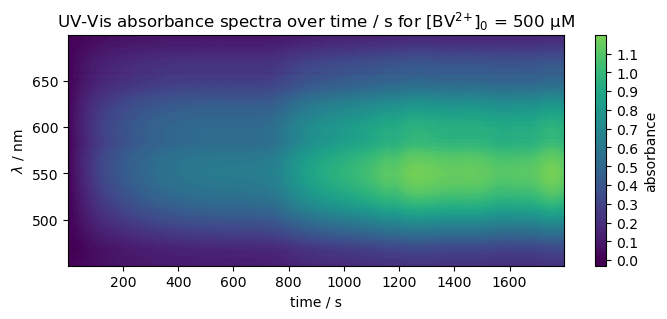

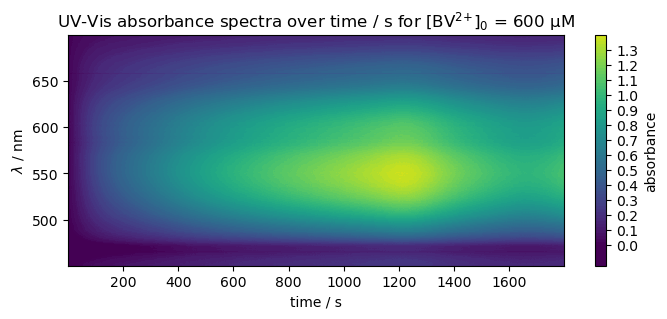

In [16]:
# uv-vis absorption spectrum over time for each run
for (v, start) in runs:
    data = f'{root}/Rubpy_BV_{v}_EDTA_Buffered'
    c0 = solprop(cstock=cstock, valiquot=v*1e-6, vsol=vsol) # initial XV2+ concentration

    t, l, a = spectrumvstime(data, start=start)
    mask = (l >= 450) & (l <= 700) 
    a = a[mask, :]
    l = l[mask]

    fig, ax = plt.subplots(figsize=(8,3))
    cf = ax.contourf(t, l, a, levels=100, vmin=0, vmax=1.5, cmap="viridis")
    ax.set_title(rf"UV-Vis absorbance spectra over time / s for {XV0} = {c0*1e6:.0f} μM")
    ax.set_xlabel("time / s")
    ax.set_ylabel(r'$\lambda$ / nm')
    cbar = plt.colorbar(cf)
    cbar.set_label("absorbance")
    cbar.set_ticks(np.arange(0, a.max(), 0.1))
    plt.show()

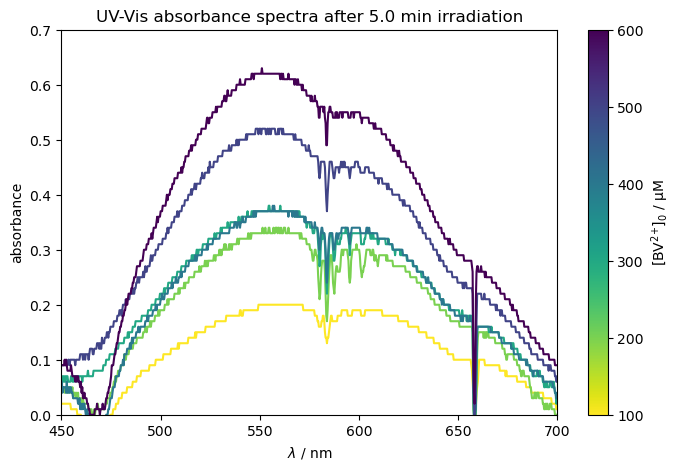

In [17]:
from matplotlib import cm as cm
from matplotlib import colors as colors

# uv-vis absorption spectrum at time t for each run
fig, ax = plt.subplots(figsize=(8,5))
cmap = plt.get_cmap("viridis_r")

t = 5*60
for i, (v, start) in enumerate(runs): # exclude the run on 260625 which did not include Rubpy in background measurement
    data = f'{root}/Rubpy_BV_{v}_EDTA_Buffered'
    l, a = spectrumvstimepoints(data, [t], start=start)
    ax.plot(l, a[0], color=cmap(i/(len(runs)-1)))

norm = colors.Normalize(vmin=0, vmax=len(runs)-1)
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_ticks(range(len(runs)))
cbar.set_ticklabels([f'{solprop(cstock=cstock, valiquot=v*1e-6, vsol=vsol)*1e6:.0f}' for v, _ in runs])
cbar.set_label(f"{XV0} / μM")

plt.title(f'UV-Vis absorbance spectra after {t/60} min irradiation')
plt.xlim(450, 700)
plt.ylim(0, 0.7)
plt.xlabel(r'$\lambda$ / nm')
plt.ylabel(r'absorbance')
plt.show()